# Neural A\* — Quantization

**Run on the compute server in a GPU Slurm session.** Distillation is the only slow part;
everything else runs fine on CPU.

```bash
srun --gres=gpu:1 --time=04:00:00 --mem=16G --pty bash
conda activate fpga_hw2
```

Needs `01_baseline.ipynb` to have run at least once (for `mazes_032_moore_c8.npz`
and the `model/` checkpoint), plus `neural_astar_core/` alongside this notebook.

### The question

An FPGA does not do float32. Before FINN can build anything it must be known how
few bits the encoder tolerates, because that number sets BRAM usage, DSP count
and achievable clock.

The unusual part of this measurement: for a classifier the check is whether
accuracy holds. Here the network's output is a **cost map that feeds a search**,
so quantization error does not produce a wrong label — it produces a *different
search*. The path may still be valid while the search does more work to find it.
`p_opt` alone would miss that entirely, which is why every configuration below is
scored on `p_opt`, `p_exp` **and** `p_gen`.

### Route

1. **Post-training quantization** — round the trained weights, change nothing
   else. Free, and it establishes how much damage bit width alone does.
2. **Distillation** — fine-tune the quantized encoder to reproduce the float
   encoder's guidance maps.
3. **Sweep** — W×A configurations against the PYNQ-Z2 memory budget.

On distillation rather than full QAT: the paper trains through the
differentiable A\* using an L1 loss between the closed list and the ground-truth
path (their Equation 7). That machinery costs O((H·W)²) per sample. Since the
search consumes nothing but the cost map, the quantized model can instead be trained
encoder to match the float encoder's cost map directly — same objective in
effect, a fraction of the compute, no differentiable A\* required. Section 5
checks whether that shortcut actually holds up.

## 0. Environment

In [1]:
import os, sys, time, copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import brevitas
import brevitas.nn as qnn
from brevitas.quant import Int8ActPerTensorFloat

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch    : {torch.__version__}")
print(f"brevitas : {brevitas.__version__}")
print(f"device   : {DEVICE}")
if DEVICE == "cpu":
    print("\nNo GPU. Distillation will be slow -- cut EPOCHS and N_TRAIN_MAPS below,")
    print("or restart in a GPU session.")

from neural_astar_core import (
    sample_problems, load_encoder_from_checkpoint,
    VanillaAStarPlanner, NeuralAStarPlanner, evaluate,
)
from neural_astar_core.grid import index_to_one_hot
from neural_astar_core.encoder import encoder_input

DATA = "mazes_032_moore_c8.npz"
CKPT = "model/mazes_032_moore_c8/lightning_logs/"
assert os.path.exists(DATA), "run 01_baseline.ipynb first (or python fetch_data.py)"

torch    : 2.5.1+cu121
brevitas : 0.12.1
device   : cuda


## 1. The float baseline

Everything below is measured against this. One fixed evaluation set for the
whole notebook, so configurations are compared on identical problems — a
different draw per config would let sampling noise masquerade as a quantization
effect.

In [2]:
EVAL_SEED = 2024
EVAL_N = 200

eval_set = sample_problems(DATA, "test", EVAL_N, seed=EVAL_SEED, starts_per_map=2)
vanilla = VanillaAStarPlanner()

float_encoder = load_encoder_from_checkpoint(CKPT, device=DEVICE)
float_report = evaluate(eval_set, vanilla, NeuralAStarPlanner(float_encoder, device=DEVICE))

print(eval_set.describe())
print()
print(f"{'':16} {'p_opt':>7} {'p_exp':>7} {'p_gen':>7}")
print(f"{'float32':16} {float_report.p_opt:7.3f} {float_report.p_exp:7.3f} "
      f"{float_report.p_gen:7.3f}")

FLOAT = dict(p_opt=float_report.p_opt, p_exp=float_report.p_exp,
             p_gen=float_report.p_gen)

200 problems | 32x32 grid | split=test | seed=2024 | source=mazes_032_moore_c8.npz

                   p_opt   p_exp   p_gen
float32            0.830   0.454   0.247


## 2. The quantized encoder

Same shape as the float model — five 3×3 convolutions, 2→32→64→128→256→1 — with
Brevitas quantizers inserted. Four choices worth explaining:

**`bias=False` on every convolution.** The float checkpoint has conv biases, but
each conv is immediately followed by BatchNorm, whose shift subsumes any bias.
Dropping them loses nothing and gives FINN one less thing to fold.

**Input quantizer is nearly free.** Channel 0 is the obstacle map and channel 1
is start+goal, both strictly 0 or 1. The input is *already binary*, so
quantizing it costs no accuracy at any width ≥ 1 bit. Rare luxury.

**`QuantReLU` between layers, `QuantIdentity` at the output.** The output
quantizer is what limits how many distinct cost values the search can see — with
`a_bits = 4` the entire guidance map is 16 levels.

**Sigmoid survives FINN.** FINN has no sigmoid primitive, but sigmoid is
monotonic, so sigmoid-then-quantize collapses into a single `MultiThreshold`
node during compilation. The thresholds absorb it. Nothing to do here beyond
keeping the quantizer directly after it.

In [3]:
class QuantGuidanceEncoder(nn.Module):
    """Quantized guidance-map encoder, architecture-matched to the checkpoint."""

    def __init__(self, weight_bits=4, act_bits=8, in_dim=2,
                 channels=(32, 64, 128, 256)):
        super().__init__()
        self.weight_bits, self.act_bits = weight_bits, act_bits
        self.in_dim, self.channels = in_dim, tuple(channels)

        widths = [in_dim] + list(channels) + [1]
        self.input_q = qnn.QuantIdentity(act_quant=Int8ActPerTensorFloat,
                                         return_quant_tensor=True)
        blocks = []
        for i in range(len(widths) - 1):
            is_last = (i == len(widths) - 2)
            blocks.append(qnn.QuantConv2d(
                widths[i], widths[i + 1], kernel_size=3, stride=1, padding=1,
                bias=False, weight_bit_width=weight_bits,
                return_quant_tensor=False))
            blocks.append(nn.BatchNorm2d(widths[i + 1]))
            if not is_last:
                blocks.append(qnn.QuantReLU(bit_width=act_bits,
                                            return_quant_tensor=True))
        self.model = nn.Sequential(*blocks)
        self.out_q = qnn.QuantIdentity(bit_width=act_bits,
                                       return_quant_tensor=False)

    def forward(self, x):
        return self.out_q(torch.sigmoid(self.model(self.input_q(x))))

    def num_parameters(self):
        return sum(p.numel() for p in self.parameters())

    def weight_bytes(self):
        """Weight storage at this bit width -- the number BRAM cares about."""
        n = sum(m.weight.numel() for m in self.modules()
                if isinstance(m, qnn.QuantConv2d))
        return n * self.weight_bits / 8


def init_from_float(quant_model, float_model):
    """Seed the quantized model with the trained float weights.

    Conv biases are absent by design (see above) and simply do not match; BN
    parameters and running statistics carry over unchanged.
    """
    fsd, qsd = float_model.state_dict(), quant_model.state_dict()
    copied = 0
    for k in qsd:
        if k in fsd and fsd[k].shape == qsd[k].shape:
            qsd[k] = fsd[k].clone()
            copied += 1
    quant_model.load_state_dict(qsd, strict=False)
    return copied


probe = QuantGuidanceEncoder(4, 8)
n_copied = init_from_float(probe, float_encoder)
print(f"parameters      : {probe.num_parameters():,}")
print(f"tensors copied  : {n_copied}")
print(f"weights @4-bit  : {probe.weight_bytes()/1024:.0f} KB")
print(f"PYNQ-Z2 BRAM    : 630 KB")

parameters      : 390,920
tensors copied  : 30
weights @4-bit  : 190 KB
PYNQ-Z2 BRAM    : 630 KB


## 3. Post-training quantization

Round the trained weights to the target width and change nothing else. This is
the cheapest thing anyone could try, so it deserves to be measured before
spend GPU time on alternatives — and if it works, no further work is needed.

In [4]:
def eval_encoder(encoder, problems=None):
    encoder.eval().to(DEVICE)
    rep = evaluate(problems or eval_set, vanilla,
                   NeuralAStarPlanner(encoder, device=DEVICE))
    return dict(p_opt=rep.p_opt, p_exp=rep.p_exp, p_gen=rep.p_gen)


PTQ_CONFIGS = [(8, 8), (4, 8), (4, 4), (2, 4)]
ptq_results = {}

for w, a in PTQ_CONFIGS:
    m = QuantGuidanceEncoder(w, a)
    init_from_float(m, float_encoder)
    ptq_results[(w, a)] = eval_encoder(m)
    r = ptq_results[(w, a)]
    print(f"W{w}A{a:<3} p_opt {r['p_opt']:.3f}  p_exp {r['p_exp']:.3f}  "
          f"p_gen {r['p_gen']:.3f}")

print(f"\n{'float':7} p_opt {FLOAT['p_opt']:.3f}  p_exp {FLOAT['p_exp']:.3f}  "
      f"p_gen {FLOAT['p_gen']:.3f}")

$HOME/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/torch/_tensor.py:1488: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1928.)
  return super().rename(names)


W8A8   p_opt 0.545  p_exp 0.250  p_gen 0.143
W4A8   p_opt 0.610  p_exp 0.232  p_gen 0.129
W4A4   p_opt 0.620  p_exp 0.242  p_gen 0.133
W2A4   p_opt 0.870  p_exp 0.217  p_gen 0.121

float   p_opt 0.830  p_exp 0.454  p_gen 0.247


Read the `p_opt` column against float before continuing. If it has collapsed,
that is the finding that motivates the rest of the notebook: the weights were
trained in float and rounding them moves the guidance map enough to change which
corridors look cheap.

Note *how* it fails. Paths mostly stay valid — the search still succeeds — but
optimality and expansion savings both degrade. Quantization here is not breaking
the network, it is degrading the *quality of the hint* the network gives A\*.

## 4. Distillation

Fine-tune the quantized encoder to reproduce the float encoder's guidance maps.
Brevitas handles the awkward part — quantization is not differentiable, so it
uses a straight-through estimator: quantize on the forward pass, pass gradients
through unchanged on the backward pass. That lets the weights adapt to the
rounding they will suffer at inference.

The training set is problem instances, not maps: each map contributes several
different start positions, because the guidance map depends on start and goal,
not just the obstacles.

In [5]:
N_TRAIN_MAPS = 800      # whole train split
STARTS_PER_MAP = 4      # 3200 instances
BATCH = 64
EPOCHS = 25
LR = 1e-4


def build_distillation_set(n_maps=N_TRAIN_MAPS, starts=STARTS_PER_MAP, seed=7):
    ps = sample_problems(DATA, "train", n_maps * starts, seed=seed,
                         starts_per_map=starts, replace=True)
    xs = [encoder_input(p.obstacle_map,
                        index_to_one_hot(p.start, p.height, p.width),
                        index_to_one_hot(p.goal, p.height, p.width)) for p in ps]
    X = torch.cat(xs, 0)
    float_encoder.eval()
    with torch.no_grad():
        Y = torch.cat([float_encoder(X[i:i+256].to(DEVICE)).cpu()
                       for i in range(0, len(X), 256)], 0)
    return X, Y


t0 = time.time()
X_train, Y_train = build_distillation_set()
print(f"{len(X_train)} instances, targets from the float encoder "
      f"({time.time()-t0:.0f}s)")

3200 instances, targets from the float encoder (1s)


In [7]:
def distil(weight_bits, act_bits, epochs=EPOCHS, lr=LR, verbose=True):
    """Fine-tune a quantized encoder to match the float guidance maps."""
    model = QuantGuidanceEncoder(weight_bits, act_bits)
    init_from_float(model, float_encoder)
    model.to(DEVICE).train()

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.L1Loss()          # L1, matching the paper's loss family
    history = []

    for ep in range(epochs):
        perm = torch.randperm(len(X_train))
        total, nb = 0.0, 0
        for i in range(0, len(X_train), BATCH):
            idx = perm[i:i + BATCH]
            xb, yb = X_train[idx].to(DEVICE), Y_train[idx].to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            total += loss.item(); nb += 1
        sched.step()
        history.append(total / max(nb, 1))
        if verbose and (ep % 5 == 0 or ep == epochs - 1):
            print(f"    epoch {ep+1:3d}/{epochs}  L1 {history[-1]:.5f}")

    return model.eval(), history


print("Distilling W4A8 ...")
t0 = time.time()
model_w4a8, hist_w4a8 = distil(4, 8)
print(f"  {time.time()-t0:.0f}s")

res = eval_encoder(model_w4a8)
print(f"\n{'':16} {'p_opt':>7} {'p_exp':>7} {'p_gen':>7}")
print(f"{'float32':16} {FLOAT['p_opt']:7.3f} {FLOAT['p_exp']:7.3f} {FLOAT['p_gen']:7.3f}")
p = ptq_results[(4, 8)]
print(f"{'W4A8 PTQ':16} {p['p_opt']:7.3f} {p['p_exp']:7.3f} {p['p_gen']:7.3f}")
print(f"{'W4A8 distilled':16} {res['p_opt']:7.3f} {res['p_exp']:7.3f} {res['p_gen']:7.3f}")

Distilling W4A8 ...
    epoch   1/25  L1 0.02157
    epoch   6/25  L1 0.01320
    epoch  11/25  L1 0.01129
    epoch  16/25  L1 0.01100
    epoch  21/25  L1 0.00986
    epoch  25/25  L1 0.00917
  103s

                   p_opt   p_exp   p_gen
float32            0.830   0.454   0.247
W4A8 PTQ           0.610   0.232   0.129
W4A8 distilled     0.835   0.451   0.245


### Does a lower L1 actually mean a better search?

The distillation loss optimises cost-map similarity, but what matters is
search behaviour. Those are related, not identical: a small error on one
critical cell can flip a decision, while a large error in an irrelevant corner
costs nothing.

Worth checking directly, because if the correlation is weak then distillation is
optimising the wrong thing and the fallback is to full QAT through the
differentiable A\*.

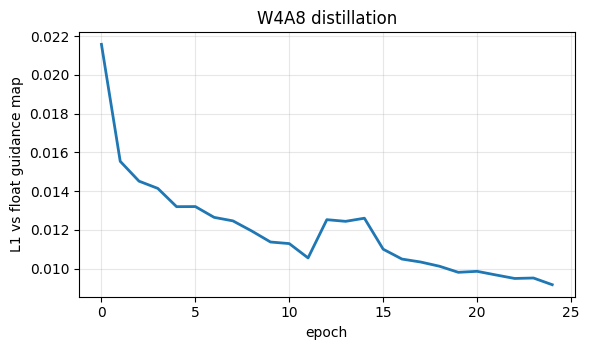

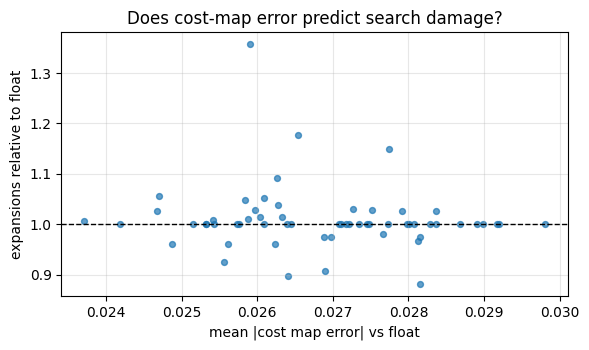

correlation: -0.106
Strongly positive means distillation is optimising the right thing.
Near zero would mean cost-map L1 is a poor proxy and full QAT through
the differentiable A* is needed instead.


In [8]:
plt.figure(figsize=(6, 3.6))
plt.plot(hist_w4a8, lw=2)
plt.xlabel("epoch"); plt.ylabel("L1 vs float guidance map")
plt.title("W4A8 distillation"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Cost-map error against search damage, per problem.
sample = list(eval_set)[:60]
errs, dexp = [], []
fp = NeuralAStarPlanner(float_encoder, device=DEVICE)
qp = NeuralAStarPlanner(model_w4a8, device=DEVICE)
for prob in sample:
    cf, _ = fp.cost_map(prob)
    cq, _ = qp.cost_map(prob)
    errs.append(float(np.abs(cf - cq).mean()))
    rf, rq = fp.plan(prob).search, qp.plan(prob).search
    dexp.append(rq.num_expansions / max(rf.num_expansions, 1))

plt.figure(figsize=(6, 3.6))
plt.scatter(errs, dexp, s=18, alpha=0.7)
plt.axhline(1.0, color="k", ls="--", lw=1)
plt.xlabel("mean |cost map error| vs float")
plt.ylabel("expansions relative to float")
plt.title("Does cost-map error predict search damage?")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f"correlation: {np.corrcoef(errs, dexp)[0,1]:+.3f}")
print("Strongly positive means distillation is optimising the right thing.")
print("Near zero would mean cost-map L1 is a poor proxy and full QAT through")
print("the differentiable A* is needed instead.")

## 5. The sweep

The result the report is built on. Each configuration is distilled from the same
float weights on the same data and scored on the same problems, so bit width is
the only variable.

Slow — roughly `EPOCHS` × 3200 instances per configuration. Trim `SWEEP` before
running for a first pass.

In [9]:
SWEEP = [(8, 8), (4, 8), (4, 4), (2, 8), (2, 4), (2, 2)]
BRAM_KB = 630

sweep_results = {}
for w, a in SWEEP:
    print(f"W{w}A{a} ...")
    t0 = time.time()
    m, _ = distil(w, a, verbose=False)
    sweep_results[(w, a)] = dict(**eval_encoder(m),
                                 kb=m.weight_bytes() / 1024,
                                 model=m)
    r = sweep_results[(w, a)]
    print(f"  p_opt {r['p_opt']:.3f}  p_exp {r['p_exp']:.3f}  "
          f"p_gen {r['p_gen']:.3f}  {r['kb']:.0f} KB  ({time.time()-t0:.0f}s)")

W8A8 ...
  p_opt 0.840  p_exp 0.457  p_gen 0.247  381 KB  (108s)
W4A8 ...
  p_opt 0.845  p_exp 0.455  p_gen 0.247  190 KB  (107s)
W4A4 ...
  p_opt 0.800  p_exp 0.435  p_gen 0.241  190 KB  (106s)
W2A8 ...
  p_opt 0.545  p_exp 0.398  p_gen 0.223  95 KB  (113s)
W2A4 ...
  p_opt 0.600  p_exp 0.391  p_gen 0.219  95 KB  (116s)
W2A2 ...
  p_opt 0.710  p_exp 0.335  p_gen 0.191  95 KB  (116s)


  config   p_opt   p_exp   p_gen   weights   % BRAM
---------------------------------------------------
 float32   0.830   0.454   0.247     1560K     248%
    W8A8   0.840   0.457   0.247      381K      60%
    W4A8   0.845   0.455   0.247      190K      30%
    W4A4   0.800   0.435   0.241      190K      30%
    W2A8   0.545   0.398   0.223       95K      15%
    W2A4   0.600   0.391   0.219       95K      15%
    W2A2   0.710   0.335   0.191       95K      15%


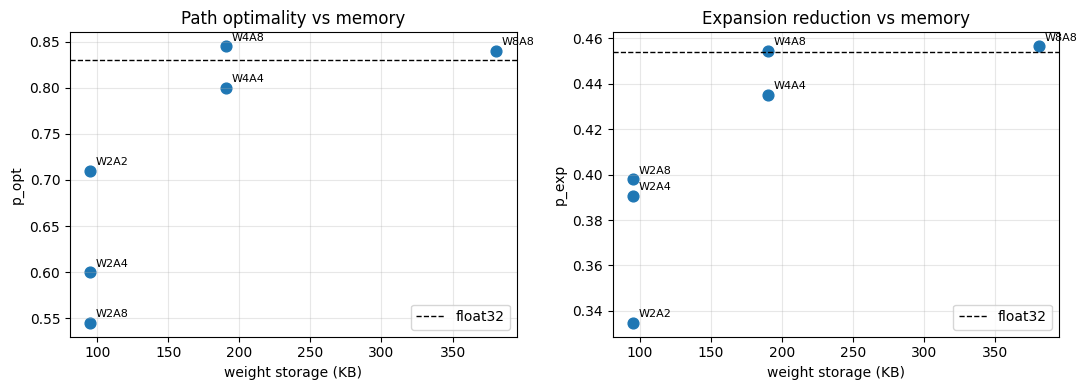

In [10]:
hdr = (f"{'config':>8} {'p_opt':>7} {'p_exp':>7} {'p_gen':>7} "
       f"{'weights':>9} {'% BRAM':>8}")
print(hdr); print("-" * len(hdr))
print(f"{'float32':>8} {FLOAT['p_opt']:7.3f} {FLOAT['p_exp']:7.3f} "
      f"{FLOAT['p_gen']:7.3f} {390*4:8.0f}K {100*390*4/BRAM_KB:7.0f}%")
for (w, a), r in sweep_results.items():
    print(f"{'W'+str(w)+'A'+str(a):>8} {r['p_opt']:7.3f} {r['p_exp']:7.3f} "
          f"{r['p_gen']:7.3f} {r['kb']:8.0f}K {100*r['kb']/BRAM_KB:7.0f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
kb = [r["kb"] for r in sweep_results.values()]
labels = [f"W{w}A{a}" for w, a in sweep_results]
for i, key in enumerate(["p_opt", "p_exp"]):
    ax[i].scatter(kb, [r[key] for r in sweep_results.values()], s=60)
    for x, lab, r in zip(kb, labels, sweep_results.values()):
        ax[i].annotate(lab, (x, r[key]), fontsize=8,
                       xytext=(4, 4), textcoords="offset points")
    ax[i].axhline(FLOAT[key], color="k", ls="--", lw=1, label="float32")
    ax[i].set_xlabel("weight storage (KB)"); ax[i].set_ylabel(key)
    ax[i].legend(); ax[i].grid(alpha=0.3)
ax[0].set_title("Path optimality vs memory")
ax[1].set_title("Expansion reduction vs memory")
plt.tight_layout(); plt.show()

This plot is the contribution. The accuracy-versus-precision frontier for a
learned planner on a fixed memory budget is not something the Neural A\* paper
reports, because the paper was never targeting hardware.

Pick the configuration at the knee — the smallest width that still tracks float
— and the report states why it was picked rather than the smallest one that fits.

## 6. Export for FINN

`export_qonnx` writes the graph FINN consumes in `03_synthesis.ipynb`. Following
the HW2 export utility, including the `BipolarQuant` scale check, which FINN
requires to be exactly 1.0.

In [11]:
from brevitas.export import export_qonnx
import onnx

CHOSEN = (4, 8)          # set from the sweep table above


def export_and_validate(model, onnx_path):
    model.eval().cpu()
    dummy = torch.zeros(1, 2, 32, 32)
    export_qonnx(model, input_t=dummy, export_path=onnx_path)

    m = onnx.load(onnx_path)
    bipolar = {n.input[1] for n in m.graph.node if n.op_type == "BipolarQuant"}
    for init in m.graph.initializer:
        if init.name not in bipolar:
            continue
        init.raw_data = np.ones(1, dtype=np.float32).tobytes()
        init.float_data[:] = []
    onnx.save(m, onnx_path)
    model.to(DEVICE)

    from collections import Counter
    ops = Counter(n.op_type for n in m.graph.node)
    print(f"exported {onnx_path}")
    print(f"  nodes: {dict(ops)}")
    if bipolar:
        print(f"  BipolarQuant scale pinned to 1.0 ({len(bipolar)} node(s))")
    return m


w, a = CHOSEN
chosen_model = sweep_results[(w, a)]["model"]
torch.save(chosen_model.state_dict(), f"quant_encoder_w{w}a{a}.pt")
export_and_validate(chosen_model, f"neural_astar_encoder_w{w}a{a}.onnx")

np.savez("finn_test_vectors.npz",
         x=X_train[:64].numpy(),
         y_float=Y_train[:64].numpy())
print("\nsaved finn_test_vectors.npz for board-side verification")

$HOME/miniforge3/envs/fpga_hw2/lib/python3.10/site-packages/brevitas/graph/equalize.py:69: UserWarning: fast_hadamard_transform package not found, using standard pytorch kernels
  warnings.warn("fast_hadamard_transform package not found, using standard pytorch kernels")


exported neural_astar_encoder_w4a8.onnx
  nodes: {'Quant': 11, 'Conv': 5, 'BatchNormalization': 5, 'Relu': 4, 'Sigmoid': 1}

saved finn_test_vectors.npz for board-side verification


## 7. What to write down

From the numbers above, not from expectation:

1. **PTQ vs distilled.** How much does rounding alone cost, and how much comes
   back? If PTQ was adequate, say so — it is a cheaper result and just as valid.
2. **The chosen configuration**, and why it beats both the smallest one that fits
   and the largest one that works.
3. **Whether cost-map L1 predicted search damage.** If the correlation was
   strong, distillation was a legitimate shortcut past the differentiable A\*,
   and that is worth stating as a methodological finding in its own right.
4. **How `p_gen` moved relative to `p_exp`.** If quantization hurts generated
   nodes more than expanded ones, the hardware cost of low precision is larger
   than the paper's metric would suggest — which is the same gap `01_baseline`
   found, showing up again from a different direction.

Then `03_synthesis.ipynb`: hand the ONNX to FINN, get resource and `Fmax`
numbers, and find out whether the estimated throughput matches what section 5
assumed.